## PT BENCHMARK

In [1]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

import sys
sys.path.insert(0, str(Path("/share/home/e2406751/Superresolution-TIR")))

from scripts.utils.dataset import SRDataset
from scripts.evaluation.eval import build_model

# Paths
BASE        = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR = BASE / "data/processed/patches"
STATS_PATH  = PATCHES_DIR / "stats.json"

with open(STATS_PATH) as f:
    stats = json.load(f)

HR_MEAN    = stats["hr"]["mean"]
HR_STD     = stats["hr"]["std"]
LR_MEAN    = stats["lr"]["mean"]
LR_STD     = stats["lr"]["std"]
DATA_RANGE = stats["hr_data_range"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Load models ONCE 
model_names = ["edsr", "swinir", "hat", "realesrgan", "resshift"]

models = {
    name: build_model(
        model_name=name,
        phase=1,
        checkpoint=None
    ).to(device).eval()
    for name in model_names
}

# Inference function
@torch.no_grad()
def get_sr(model_name, sample):
    lr = sample["lr"].unsqueeze(0).to(device)
    sr = models[model_name](lr)

    sr_celsius = sr[:, 0:1] * HR_STD + HR_MEAN
    return sr_celsius.squeeze().cpu().numpy()

[INFO] Loading EDSR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Loaded 68/74 layers


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[INFO] loaded 550 SwinIR layers
[INFO] Fetching HAT arch from GitHub...
[INFO] Loading HAT pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/HAT_imagenet_x4.pth
[INFO] Loaded 864/864 layers
[INFO] Loading RealESRGAN generator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_generator_x4.pth
[INFO] Generator: loaded 702/702 layers
[INFO] Phase 1 — inference only, no discriminator


In [3]:
# Dataset
test_ds = SRDataset(
    split="test",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    repeat_channels=True,
    transform=None,
)

# deterministic sampling (recommended for thesis reproducibility)
# random.seed(42)
# np.random.seed(42)

N_SAMPLES = 1
indices = np.random.choice(len(test_ds), N_SAMPLES, replace=False)
samples = [test_ds[i] for i in indices]

print(f"Selected tiles: {[s['fname'] for s in samples]}")

Selected tiles: ['BRC_2022_b0_r768_c512.npy']


In [ ]:
# Plot
for s_idx, sample in enumerate(samples):

    fname   = sample["fname"]
    hr_mask = sample["hr_mask"].squeeze().numpy()   # (256, 256)

    # LR mask to flight footprint
    lr_raw = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_up = np.repeat(np.repeat(lr_raw, 4, axis=0), 4, axis=1)
    lr_np = np.where(hr_mask > 0.5, lr_up, np.nan)

    # HR — mask to flight footprint
    hr_np = (sample["hr"][0].numpy() * HR_STD + HR_MEAN)
    hr_np = np.where(hr_mask > 0.5, hr_np, np.nan)

    valid = hr_np[hr_mask > 0.5]
    vmin, vmax = np.nanmin(valid), np.nanmax(valid)

    n_rows = len(model_names)
    n_cols = 4

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    fig.suptitle(f"Phase 1 Inference ", fontsize=12, fontweight="bold")

    for m_idx, model_name in enumerate(model_names):

        sr_np = get_sr(model_name, sample)
        sr_np = np.where(hr_mask > 0.5, sr_np, np.nan)

        residual = sr_np - hr_np
        residual = np.where(hr_mask > 0.5, residual, np.nan)

        res_lim = np.nanmax(np.abs(residual)) if np.isfinite(residual).any() else 5

        # ── LR ──
        im = axes[m_idx, 0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 0].set_title("LR")
        axes[m_idx, 0].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 0], fraction=0.046)

        # ── SR ──
        im = axes[m_idx, 1].imshow(sr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 1].set_title(f"{model_name.upper()} SR")
        axes[m_idx, 1].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 1], fraction=0.046)

        # ── HR ──
        im = axes[m_idx, 2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 2].set_title("HR GT")
        axes[m_idx, 2].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 2], fraction=0.046)

        # ── Residual ──
        im = axes[m_idx, 3].imshow(residual, cmap="bwr",
                                   vmin=-res_lim, vmax=res_lim)
        axes[m_idx, 3].set_title("Residual (°C)")
        axes[m_idx, 3].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 3], fraction=0.046)

    plt.tight_layout()
    plt.show()

## FT BENCHMARK

In [7]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# paths and stats
BASE        = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR = BASE / "data/processed/patches"
STATS_PATH  = PATCHES_DIR / "stats.json"
PRETRAINED  = BASE / "data/pretrained"

with open(STATS_PATH) as f:
    stats = json.load(f)

HR_MEAN    = stats["hr"]["mean"]
HR_STD     = stats["hr"]["std"]
LR_MEAN    = stats["lr"]["mean"]
LR_STD     = stats["lr"]["std"]
DATA_RANGE = stats["hr_data_range"]

# checkpoints for evaluation
CHECKPOINTS = {
    "edsr":       BASE / "checkpoints/phase2/edsr/edsr_phase2_epoch=69_val_psnr=20.9760.ckpt",
    "swinir":     BASE / "checkpoints/phase2/swinir/swinir_phase2_epoch=21_val_psnr=21.6563.ckpt",
    "hat":        BASE / "checkpoints/phase2/hat/hat_phase2_epoch=16_val_psnr=21.2140.ckpt",
    "realesrgan": BASE / "checkpoints/phase2/realesrgan/realesrgan_phase2_epoch=33_val_psnr=19.9362.ckpt",
}


In [10]:
# Load dataset 
import sys
sys.path.insert(0, str(BASE))
from scripts.utils.dataset import SRDataset

test_ds = SRDataset(
    split="test",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    repeat_channels=True,
    transform=None,
)

# Pick random indices once — same tiles used for all models
# np.random.seed(42)  # change seed to get different tiles
N_SAMPLES = 1
total     = len(test_ds)
indices   = np.random.choice(total, N_SAMPLES, replace=False)
samples   = [test_ds[i] for i in indices]
print(f"Selected tiles: {[s['fname'] for s in samples]}")

Selected tiles: ['HAUT_2025_b0_r1280_c4096.npy']


In [8]:
# Load model and run inference 
def get_sr(model_name, sample, phase=2):
    common = dict(hr_mean=HR_MEAN, hr_std=HR_STD,
                  data_range=DATA_RANGE, phase=phase)

    if model_name == "edsr":
        from scripts.models.edsr import EDSRModule
        model = EDSRModule.load_from_checkpoint(
            CHECKPOINTS[model_name], **common)
    elif model_name == "swinir":
        from scripts.models.swinir import SwinIRModule
        model = SwinIRModule.load_from_checkpoint(
            CHECKPOINTS[model_name], **common)
    elif model_name == "hat":
        from scripts.models.hat import HATModule
        model = HATModule.load_from_checkpoint(
            CHECKPOINTS[model_name], **common)
    elif model_name == "realesrgan":
        from scripts.models.realesrgan import RealESRGANModule
        model = RealESRGANModule.load_from_checkpoint(
            CHECKPOINTS[model_name], **common)

    model.eval().cuda()

    with torch.no_grad():
        lr = sample["lr"].unsqueeze(0).cuda()
        sr = model(lr)

    # Denormalise ch0 to Celsius
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()
    del model
    torch.cuda.empty_cache()
    return sr_celsius

/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


[INFO] Loading EDSR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Loaded 68/74 layers


[INFO] Loading SwinIR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_classical_x4.pth
[INFO] Loaded 550/550 layers
[INFO] Loading HAT pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/HAT_imagenet_x4.pth
[INFO] Loaded 864/864 layers
[INFO] Loading RealESRGAN generator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_generator_x4.pth
[INFO] Generator: loaded 702/702 layers
[INFO] Loading RealESRGAN discriminator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_discriminator_x4.pth
[INFO] Discriminator: loaded 28/28 layers


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[INFO] Phase 2 — GAN training enabled


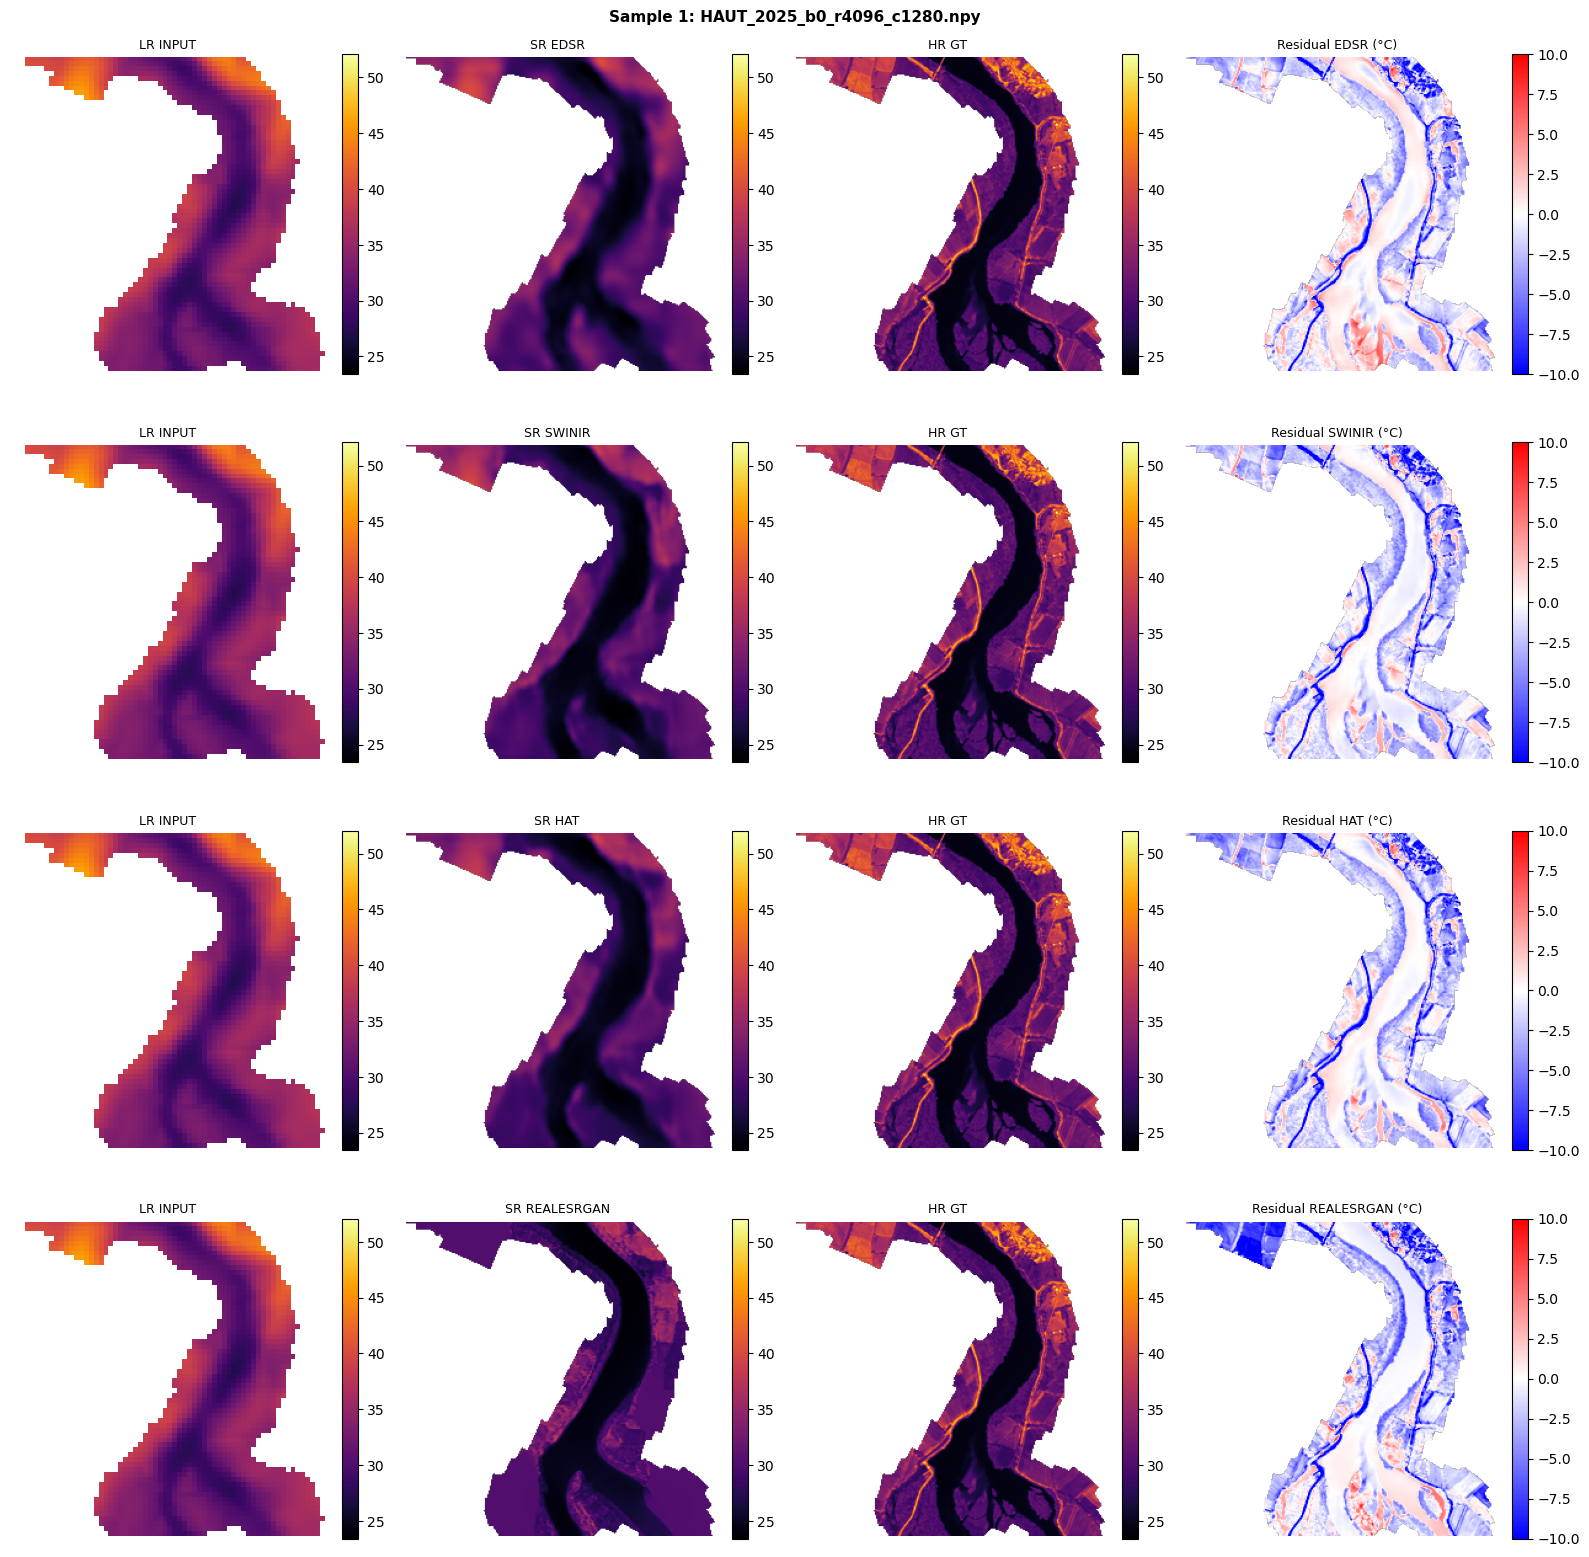

In [ ]:
#  Plot 
model_names = ["edsr", "swinir", "hat", "realesrgan"]

import torch.nn.functional as F

for s_idx, sample in enumerate(samples):
    fname   = sample["fname"]
    hr_mask = sample["hr_mask"].squeeze().numpy()   # (256, 256)

    lr_raw = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_up = np.repeat(np.repeat(lr_raw, 4, axis=0), 4, axis=1)
    lr_np = np.where(hr_mask > 0.5, lr_up, np.nan)

    # HR — mask to flight footprint
    hr_np = (sample["hr"][0].numpy() * HR_STD + HR_MEAN)
    hr_np = np.where(hr_mask > 0.5, hr_np, np.nan)

    valid = hr_np[hr_mask > 0.5]
    vmin, vmax = np.nanmin(valid), np.nanmax(valid)

    n_rows = len(model_names)
    n_cols = 4   # LR↑ | SR | HR | Residual

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 4, n_rows * 4))
    fig.suptitle(f"Sample {s_idx+1}: {fname}", fontsize=11,
                 fontweight="bold")

    for m_idx, model_name in enumerate(model_names):
        row = m_idx
        try:
            sr_np     = get_sr(model_name, sample)
            sr_np     = np.where(hr_mask > 0.5, sr_np, np.nan)
            residual  = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)
            valid_res = residual[hr_mask > 0.5]
            res_lim   = min(np.nanmax(np.abs(valid_res)), 10) \
                        if valid_res.size > 0 else 5

            # Col 0 — LR upsampled + masked
            im = axes[row, 0].imshow(lr_np, cmap="inferno",
                                     vmin=vmin, vmax=vmax)
            axes[row, 0].set_title(
                f"LR INPUT", fontsize=9)
            axes[row, 0].axis("off")
            plt.colorbar(im, ax=axes[row, 0], fraction=0.046)

            # Col 1 — SR
            im = axes[row, 1].imshow(sr_np, cmap="inferno",
                                     vmin=vmin, vmax=vmax)
            axes[row, 1].set_title(f"SR {model_name.upper()}", fontsize=9)
            axes[row, 1].axis("off")
            plt.colorbar(im, ax=axes[row, 1], fraction=0.046)

            # Col 2 — HR
            im = axes[row, 2].imshow(hr_np, cmap="inferno",
                                     vmin=vmin, vmax=vmax)
            axes[row, 2].set_title(f"HR GT", fontsize=9)
            axes[row, 2].axis("off")
            plt.colorbar(im, ax=axes[row, 2], fraction=0.046)

            # Col 3 — Residual
            im = axes[row, 3].imshow(residual, cmap="bwr",
                                     vmin=-res_lim, vmax=res_lim)
            axes[row, 3].set_title(
                f"Residual {model_name.upper()} (°C)", fontsize=9)
            axes[row, 3].axis("off")
            plt.colorbar(im, ax=axes[row, 3], fraction=0.046)

        except Exception as e:
            print(f"[ERROR] {model_name}: {e}")
            for c in range(n_cols):
                axes[row, c].axis("off")

    plt.tight_layout()
    plt.show()

## MODEL DEVELOPMENT

In [1]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

BASE        = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR = BASE / "data/processed/patches"
STATS_PATH  = PATCHES_DIR / "stats.json"
METADATA_PATH = PATCHES_DIR / "metadata.json"

sys.path.insert(0, str(BASE))

with open(STATS_PATH) as f:
    stats = json.load(f)

HR_MEAN    = stats["hr"]["mean"]
HR_STD     = stats["hr"]["std"]
LR_MEAN    = stats["lr"]["mean"]
LR_STD     = stats["lr"]["std"]
DATA_RANGE = stats["hr_data_range"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
#  Dataset 
from scripts.utils.dataset import SRDataset

test_ds = SRDataset(
    split="test",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    # metadata_path=METADATA_PATH,
    use_aux=True,
    use_water_mask=True,  
    aux_dir=str(PATCHES_DIR / "test" / "AUX"),
    repeat_channels=False,
    transform=None,
)

In [6]:
sample = test_ds[0]
sample

{'lr': tensor([[[-0.1184, -0.0958, -0.0182,  ...,  0.2142,  0.2011,  0.1597],
          [-0.0493, -0.0629, -0.0413,  ...,  0.1901,  0.1659,  0.1260],
          [-0.0092, -0.0516, -0.0638,  ...,  0.1619,  0.1285,  0.0903],
          ...,
          [ 0.5023,  0.5751,  0.6518,  ..., -0.5251, -0.4567, -0.3329],
          [ 0.6195,  0.7372,  0.8492,  ..., -0.4720, -0.3747, -0.2491],
          [ 0.7068,  0.8708,  1.0045,  ..., -0.4042, -0.2926, -0.1737]]]),
 'hr': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 'hr_mask': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0.,

In [8]:
from scripts.models.swinir import SwinIRModule

# determine the number of aux channels from the dataset
sample = test_ds[0]
in_aux_chans = sample["aux"].shape[0]

# Load the model with explicit architecture params
model = SwinIRModule.load_from_checkpoint(
    checkpoint_path=str(BASE / "checkpoints/dev_v2/swinir/best-epoch=78-val_full_psnr=18.3169.ckpt"),
    adaptation_strategy="projection",
    in_aux_chans=in_aux_chans, 
    hr_mean=HR_MEAN,
    hr_std=HR_STD,
    data_range=DATA_RANGE,
    # time_mode="time",
)

model = model.to(device).eval()

# checkpoints
# best-epoch=97-val_full_psnr=18.3156.ckpt   #projection
# best-epoch=80-val_full_psnr=17.5726.ckpt   #direct
# best-epoch=68-val_full_psnr=18.0997.ckpt   #fusion
# best-epoch=78-val_full_psnr=18.3169.ckpt   #projection + water loss + weighted water loss
# best-epoch=78-val_full_psnr=18.3035.ckpt   #projection + grad loss
# best-epoch=90-val_full_psnr=18.2759.ckpt   #projection + water + grad loss + weighted water
# best-epoch=59-val_full_psnr=18.6688.ckpt   #projection + water + grad loss + time (initial before cond variable)
# best-epoch=97-val_full_psnr=18.5713.ckpt   #projection + water + grad loss + time (date only)
# best-epoch=59-val_full_psnr=18.6878.ckpt   #projection + water + grad loss + time (time only)

[INFO] Loaded  : 550 weights


In [4]:
# Fix seed ONCE — same tiles used across all plots
np.random.seed(42)
N_SAMPLES = 4
indices   = np.random.choice(len(test_ds), N_SAMPLES, replace=False)
samples   = [test_ds[i] for i in indices]
print(f"Selected tiles: {[s['fname'] for s in samples]}")

Selected tiles: ['HAUT_2025_b0_r4608_c1536.npy', 'HAUT_2025_b0_r5120_c2304.npy', 'BRC_2022_b0_r0_c0.npy', 'HAUT_2025_b0_r3840_c3584.npy']


In [5]:
def prep_sample(sample):
    hr_mask = sample["hr_mask"].squeeze().numpy()
    lr_64   = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256  = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    lr_np   = np.where(hr_mask > 0.5, lr_256, np.nan)
    hr_np   = sample["hr"][0].numpy() * HR_STD + HR_MEAN
    hr_np   = np.where(hr_mask > 0.5, hr_np, np.nan)

    valid = hr_np[hr_mask > 0.5]

    # BEFORE: vmin, vmax = np.nanmin(valid), np.nanmax(valid)
    # AFTER: use percentiles to stop outlier pixels dominating the scale
    vmin = np.nanpercentile(valid, 2)
    vmax = np.nanpercentile(valid, 98)

    return lr_np, hr_np, hr_mask, vmin, vmax

### projected aux

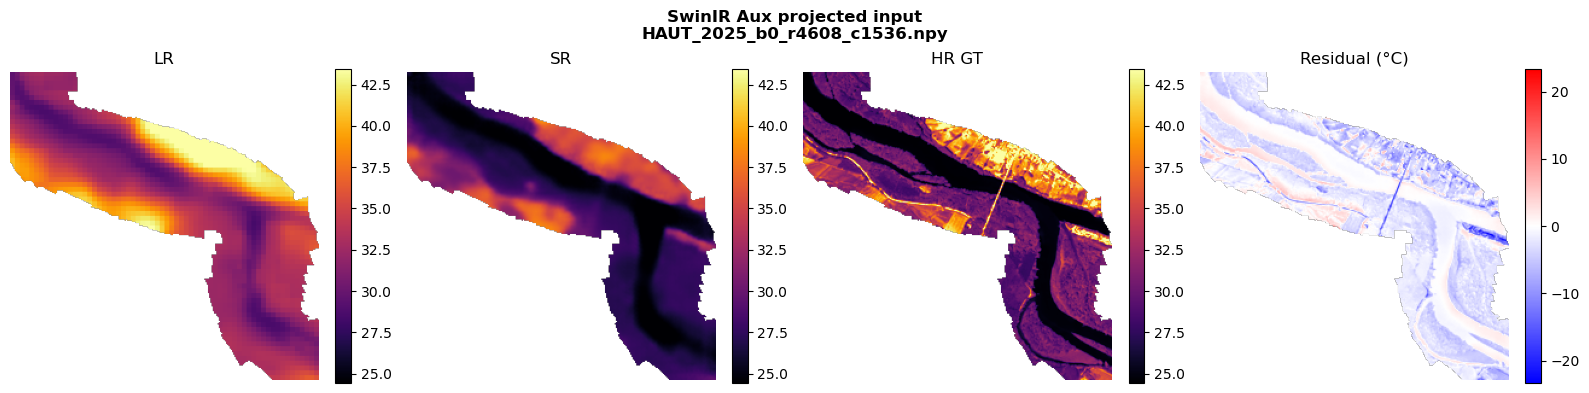

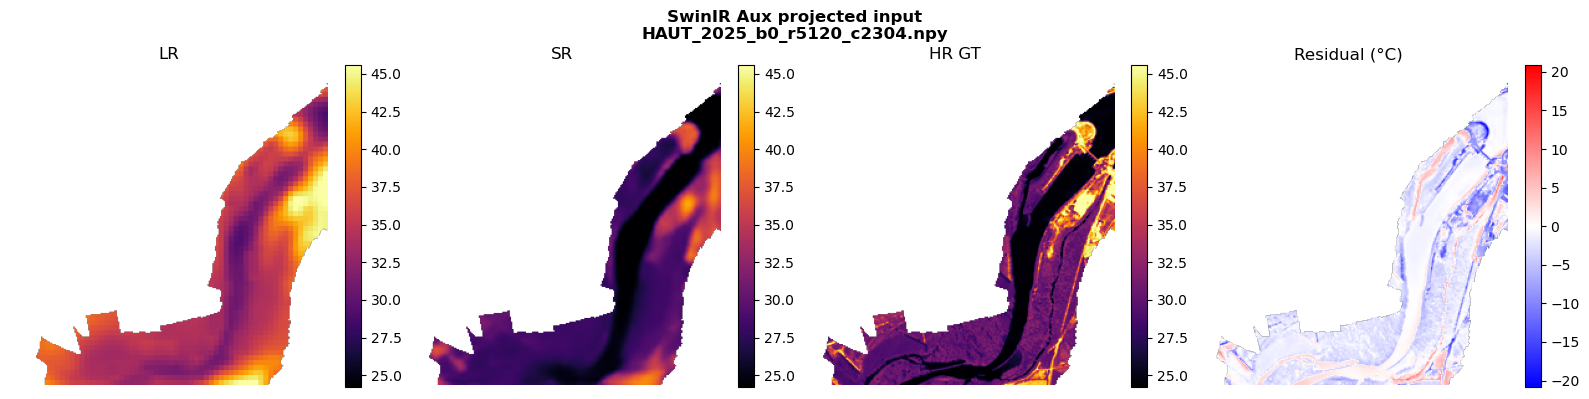

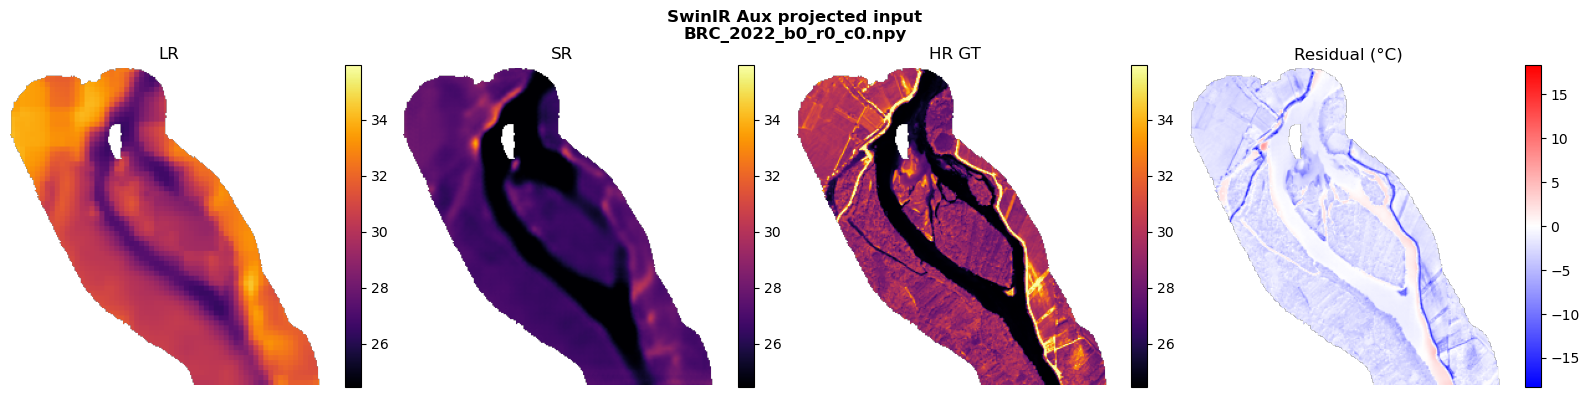

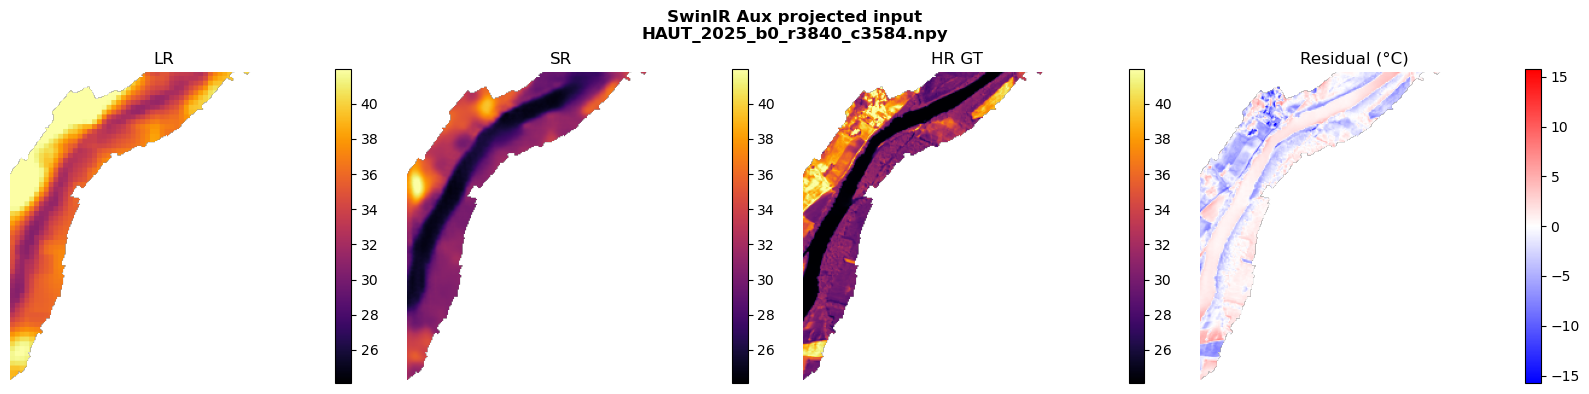

In [6]:
# Plot results
for s_idx, sample in enumerate(samples):

    fname = sample["fname"]

    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # Build batch for model
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}

    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        sr = model(batch)

    # Denormalize SR
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()

    #mask invalid regions
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    # Residual
    residual = sr_celsius - hr_np

    res_lim = (np.nanmax(np.abs(residual))if np.isfinite(residual).any()else 5)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    fig.suptitle(f"SwinIR Aux projected input\n{fname}",fontsize=12,fontweight="bold")

    # LR
    im = axes[0].imshow(lr_np,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[0].set_title("LR")
    axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    # SR
    im = axes[1].imshow(sr_celsius,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[1].set_title("SR")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # HR
    im = axes[2].imshow( hr_np,cmap="inferno", vmin=vmin,vmax=vmax)
    axes[2].set_title("HR GT")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Residual
    im = axes[3].imshow(residual,cmap="bwr",vmin=-res_lim,vmax=res_lim)
    axes[3].set_title("Residual (°C)")
    axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

    torch.cuda.empty_cache()

### modified first layer

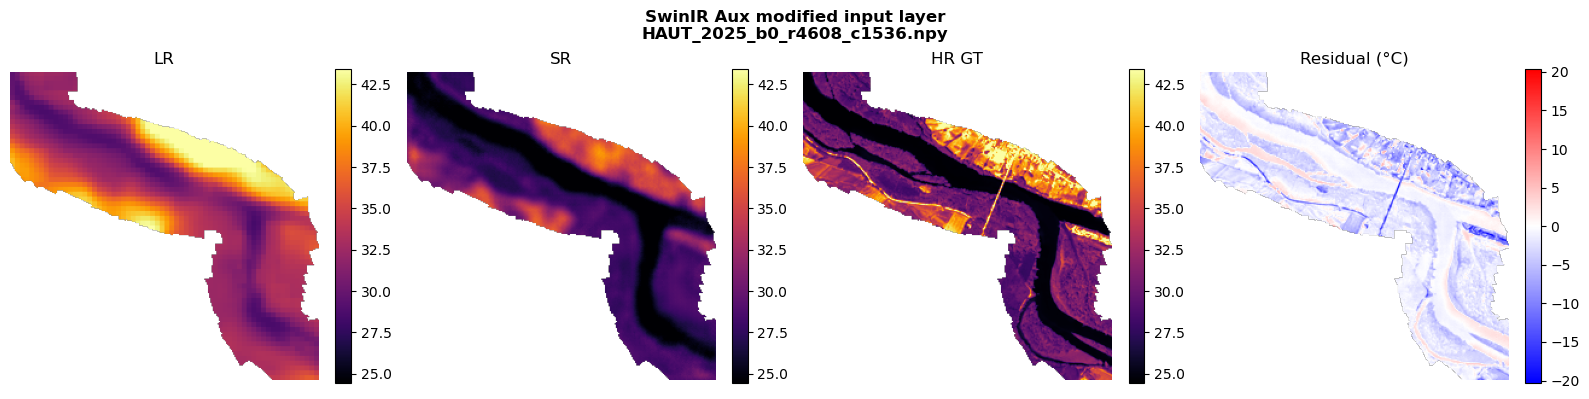

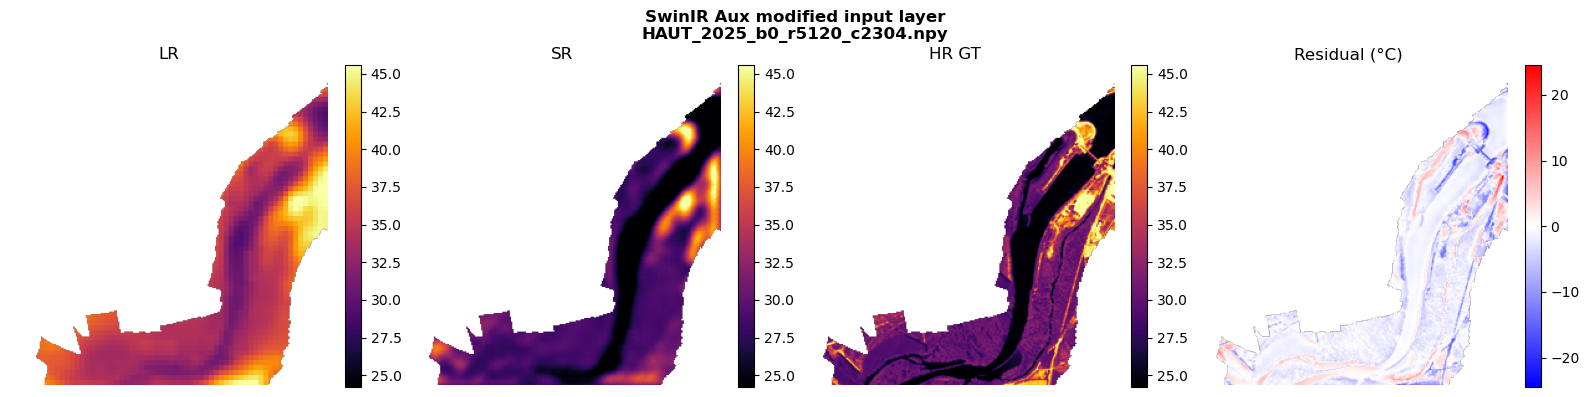

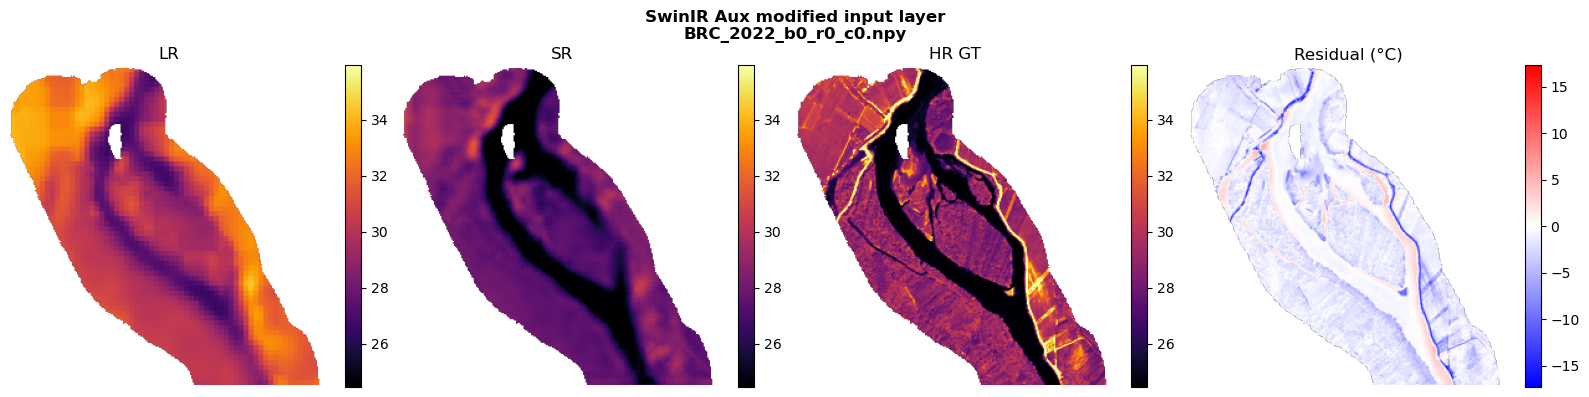

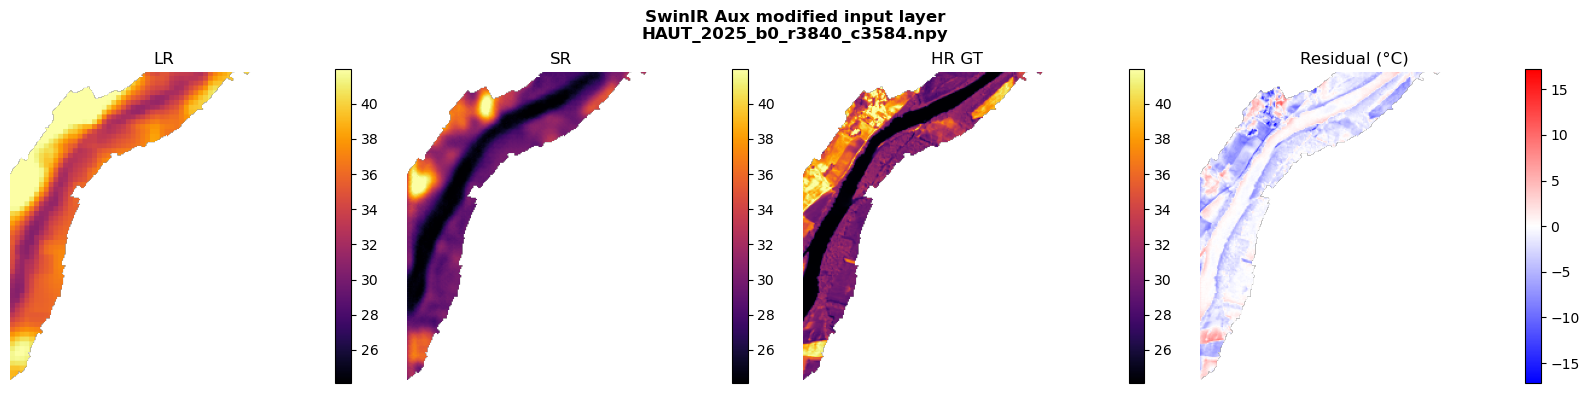

In [9]:
# Plot results
for s_idx, sample in enumerate(samples):

    fname = sample["fname"]

    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # Build batch for model
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}

    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        sr = model(batch)

    # Denormalize SR
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()

    #mask invalid regions
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    # Residual
    residual = sr_celsius - hr_np

    res_lim = (np.nanmax(np.abs(residual))if np.isfinite(residual).any()else 5)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    fig.suptitle(f"SwinIR Aux modified input layer\n{fname}",fontsize=12,fontweight="bold")

    # LR
    im = axes[0].imshow(lr_np,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[0].set_title("LR")
    axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    # SR
    im = axes[1].imshow(sr_celsius,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[1].set_title("SR")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # HR
    im = axes[2].imshow( hr_np,cmap="inferno", vmin=vmin,vmax=vmax)
    axes[2].set_title("HR GT")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Residual
    im = axes[3].imshow(residual,cmap="bwr",vmin=-res_lim,vmax=res_lim)
    axes[3].set_title("Residual (°C)")
    axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

    torch.cuda.empty_cache()

### fusion

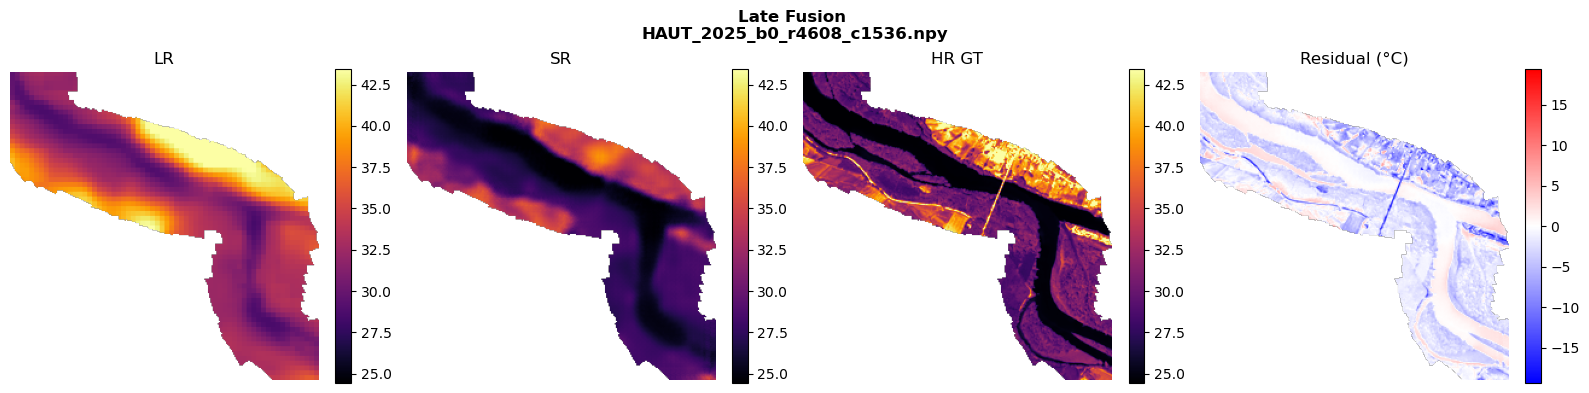

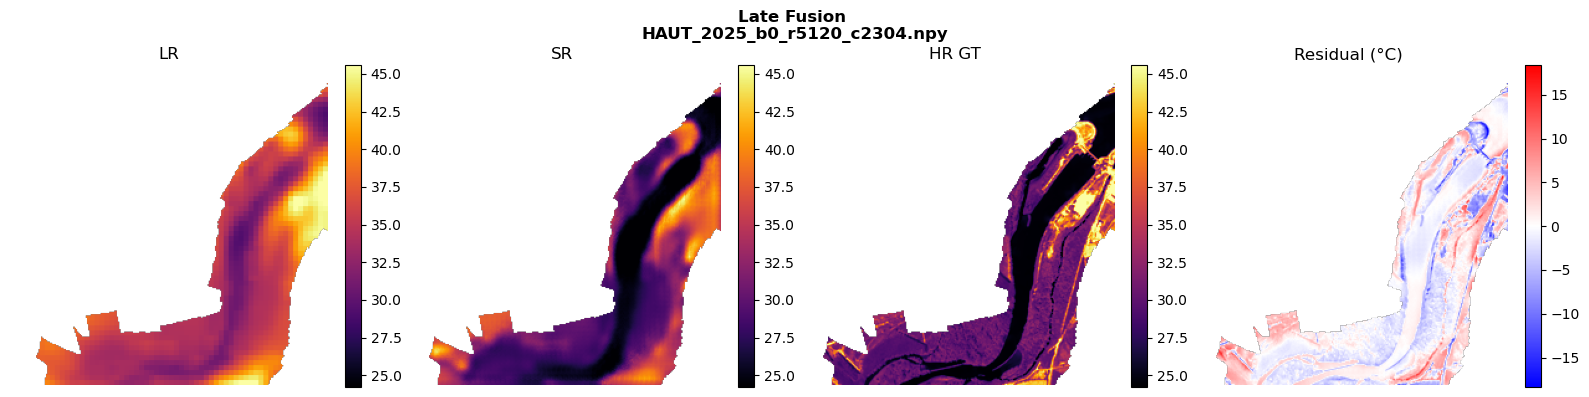

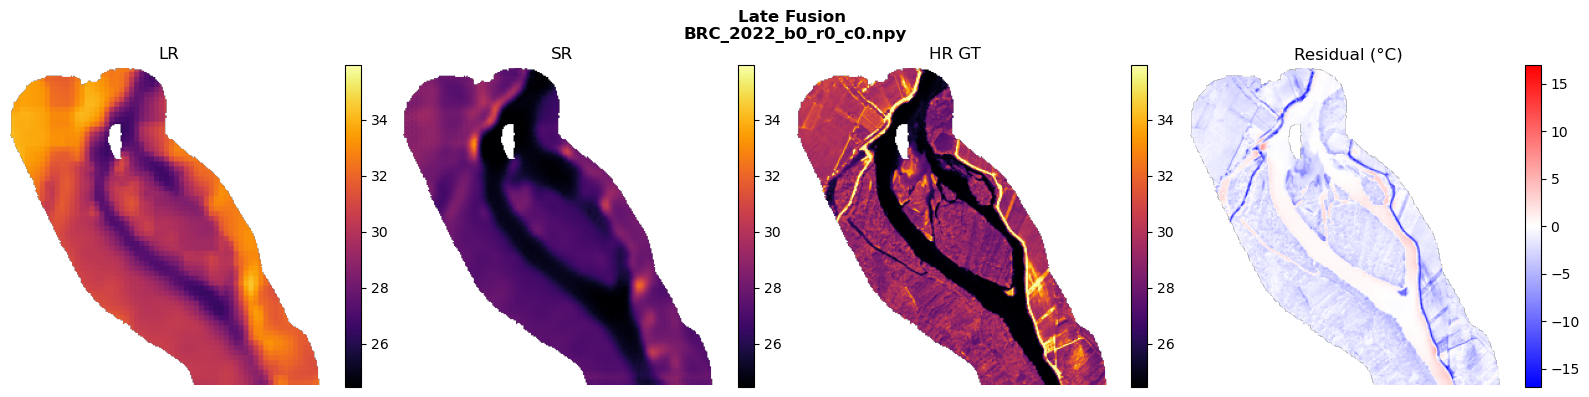

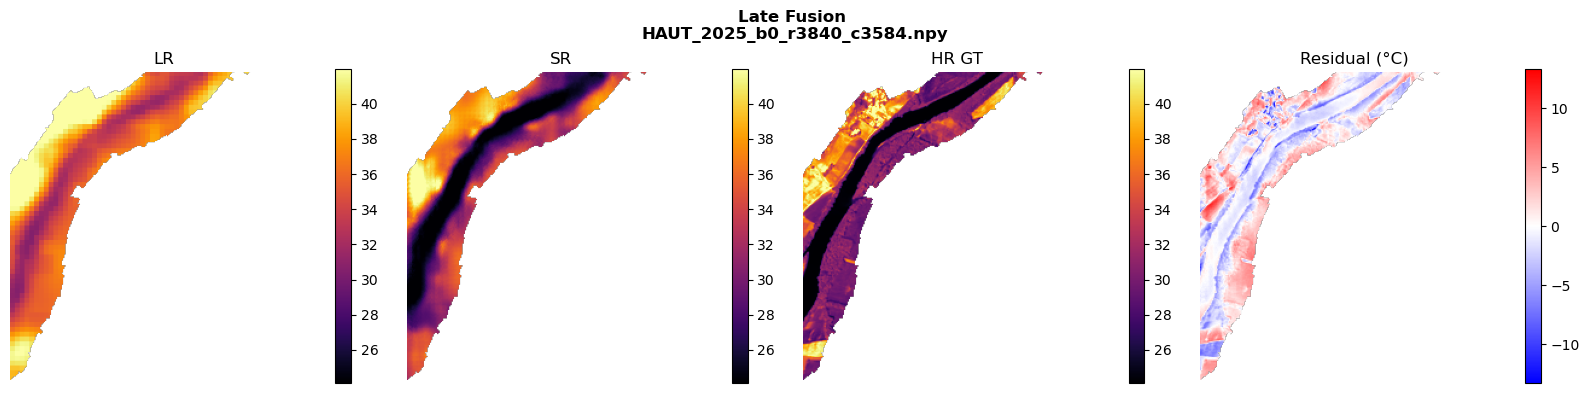

In [22]:
# Plot results
for s_idx, sample in enumerate(samples):

    fname = sample["fname"]

    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # Build batch for model
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}

    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        sr = model(batch)

    # Denormalize SR
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()

    #mask invalid regions
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    # Residual
    residual = sr_celsius - hr_np

    res_lim = (np.nanmax(np.abs(residual))if np.isfinite(residual).any()else 5)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    fig.suptitle(f"Late Fusion \n{fname}",fontsize=12,fontweight="bold")

    # LR
    im = axes[0].imshow(lr_np,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[0].set_title("LR")
    axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    # SR
    im = axes[1].imshow(sr_celsius,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[1].set_title("SR")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # HR
    im = axes[2].imshow( hr_np,cmap="inferno", vmin=vmin,vmax=vmax)
    axes[2].set_title("HR GT")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Residual
    im = axes[3].imshow(residual,cmap="bwr",vmin=-res_lim,vmax=res_lim)
    axes[3].set_title("Residual (°C)")
    axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

    torch.cuda.empty_cache()

### loss tests

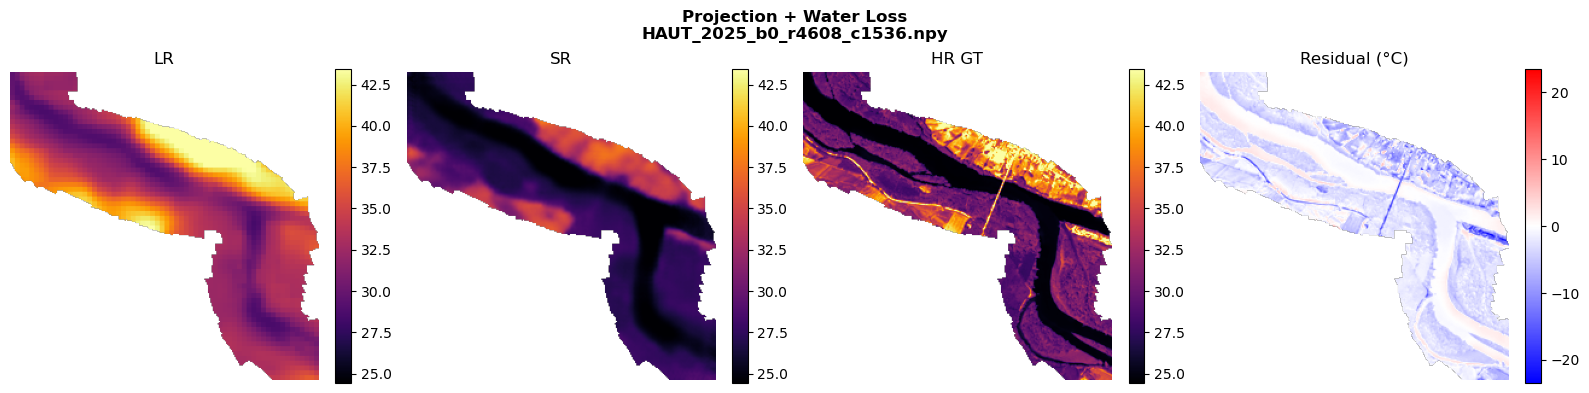

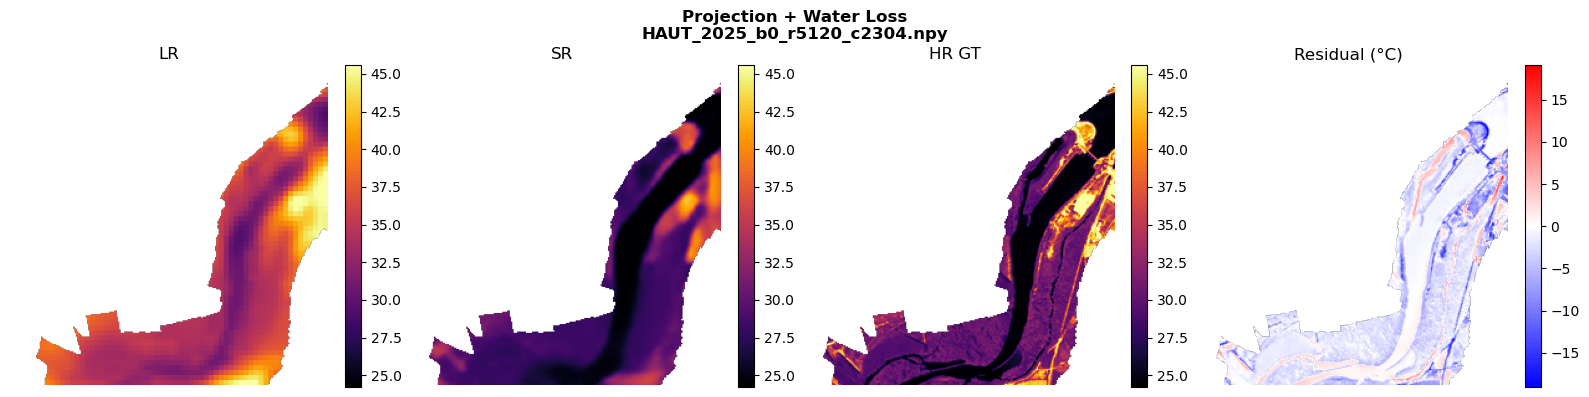

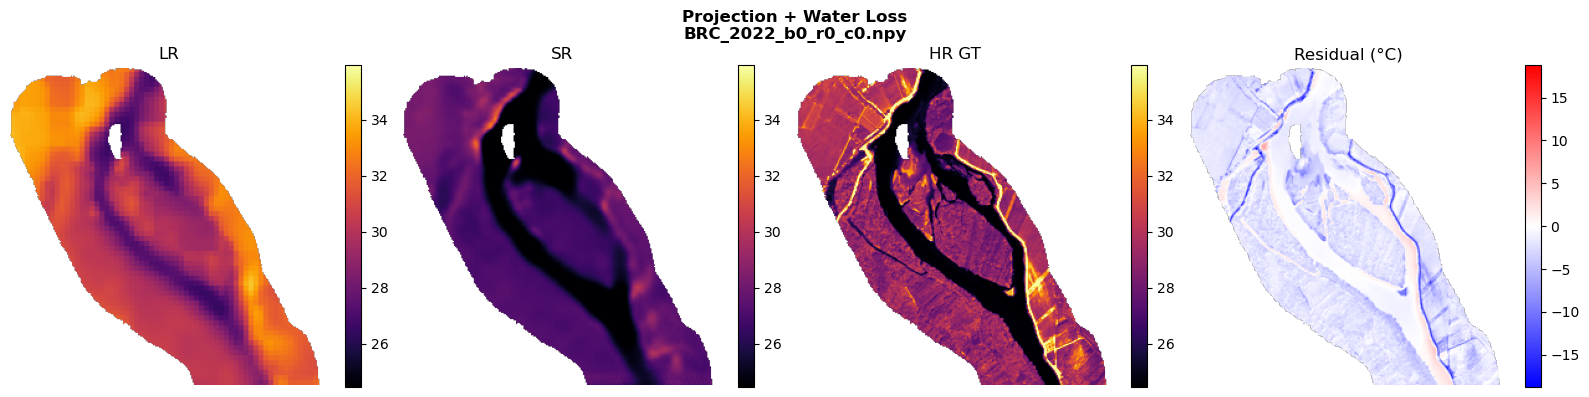

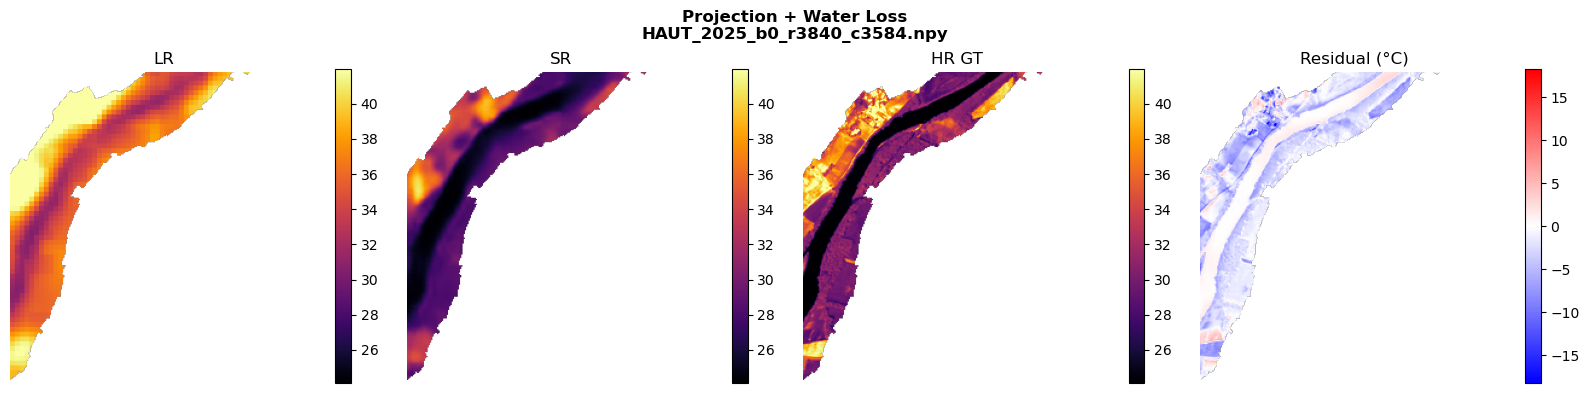

In [9]:
# Plot results
for s_idx, sample in enumerate(samples):

    fname = sample["fname"]

    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # Build batch for model
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}

    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        sr = model(batch)

    # Denormalize SR
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()

    #mask invalid regions
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    # Residual
    residual = sr_celsius - hr_np

    res_lim = (np.nanmax(np.abs(residual))if np.isfinite(residual).any()else 5)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    fig.suptitle(f"Projection + Water Loss\n{fname}",fontsize=12,fontweight="bold")

    # LR
    im = axes[0].imshow(lr_np,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[0].set_title("LR")
    axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    # SR
    im = axes[1].imshow(sr_celsius,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[1].set_title("SR")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # HR
    im = axes[2].imshow( hr_np,cmap="inferno", vmin=vmin,vmax=vmax)
    axes[2].set_title("HR GT")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Residual
    im = axes[3].imshow(residual,cmap="bwr",vmin=-res_lim,vmax=res_lim)
    axes[3].set_title("Residual (°C)")
    axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

    torch.cuda.empty_cache()

### Late fusion

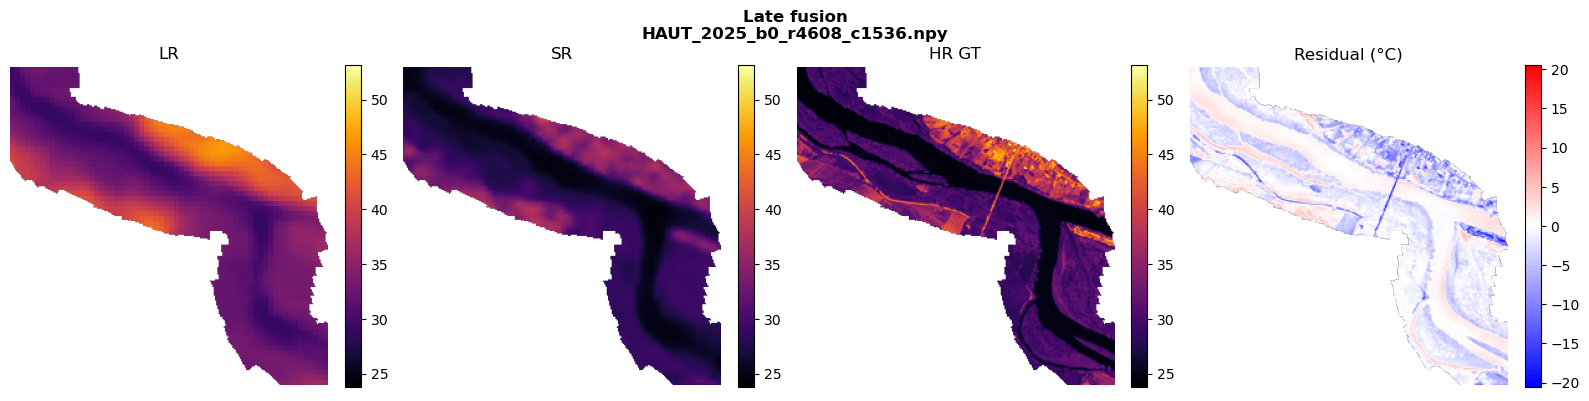

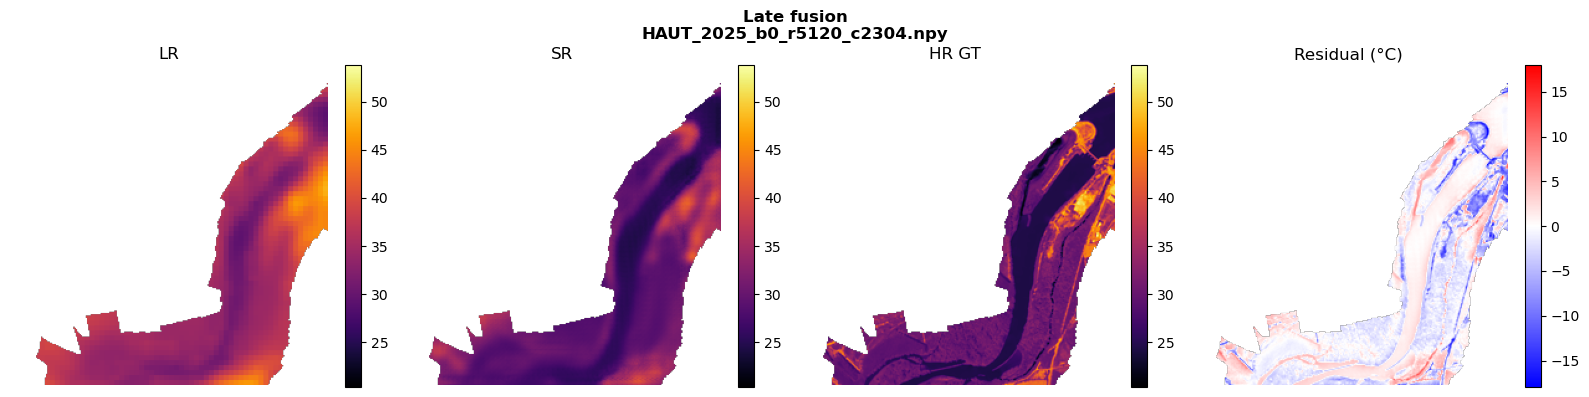

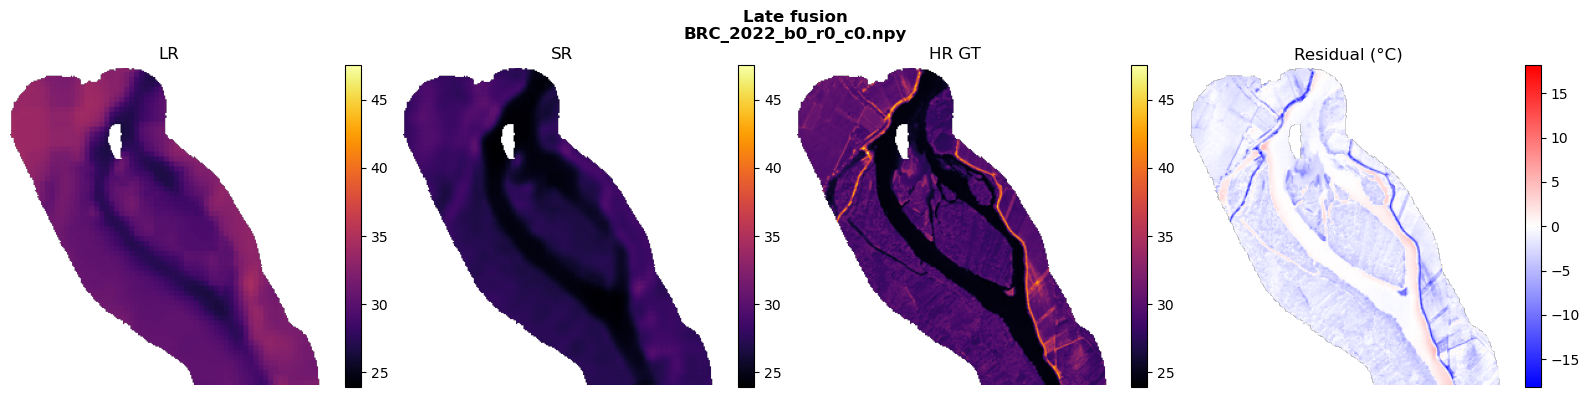

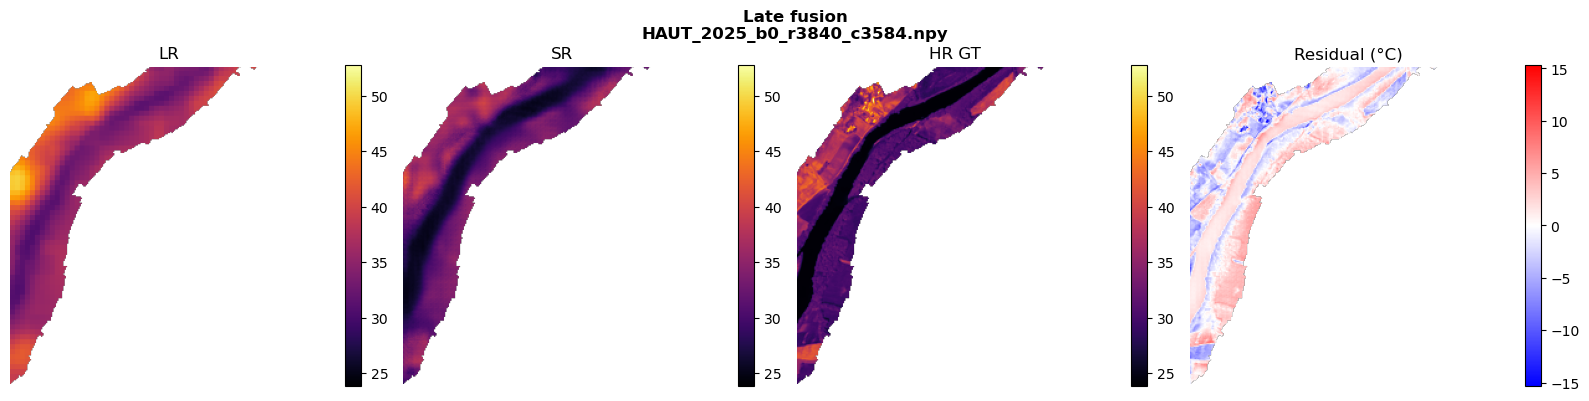

In [15]:
# Plot results
for s_idx, sample in enumerate(samples):

    fname = sample["fname"]

    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # Build batch for model
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}

    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        sr = model(batch)

    # Denormalize SR
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()

    #mask invalid regions
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    # Residual
    residual = sr_celsius - hr_np

    res_lim = (np.nanmax(np.abs(residual))if np.isfinite(residual).any()else 5)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    fig.suptitle(f"Late fusion\n{fname}",fontsize=12,fontweight="bold")

    # LR
    im = axes[0].imshow(lr_np,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[0].set_title("LR")
    axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    # SR
    im = axes[1].imshow(sr_celsius,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[1].set_title("SR")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # HR
    im = axes[2].imshow( hr_np,cmap="inferno", vmin=vmin,vmax=vmax)
    axes[2].set_title("HR GT")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Residual
    im = axes[3].imshow(residual,cmap="bwr",vmin=-res_lim,vmax=res_lim)
    axes[3].set_title("Residual (°C)")
    axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

    torch.cuda.empty_cache()

### Time conditioning

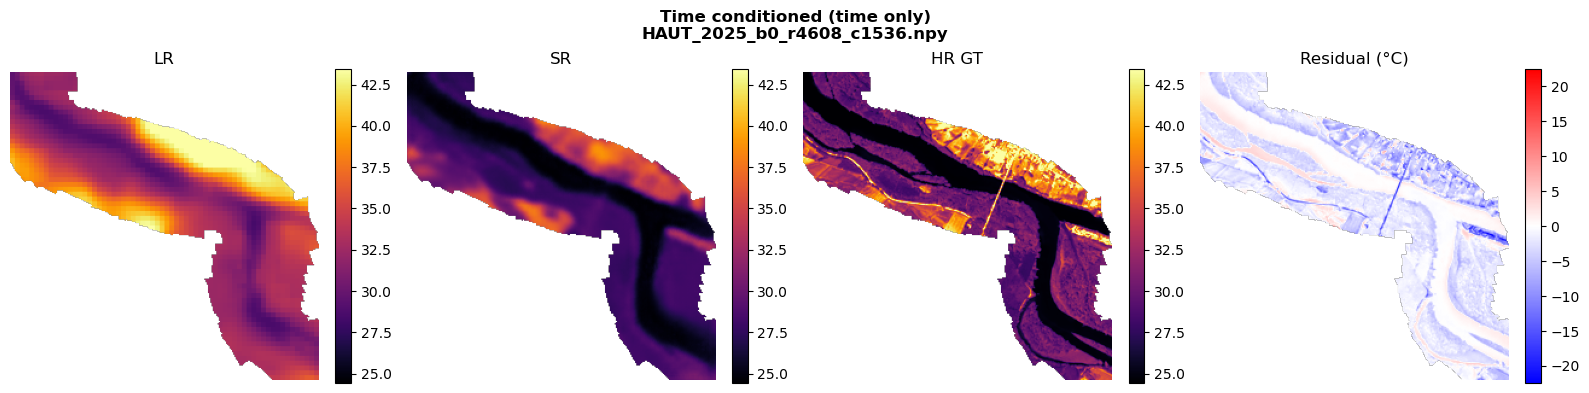

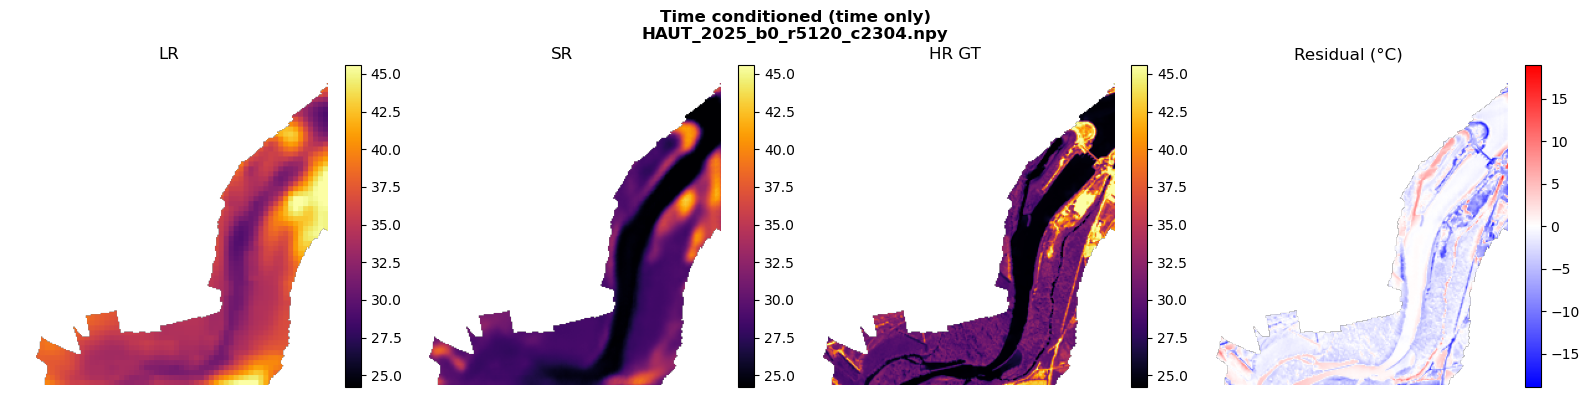

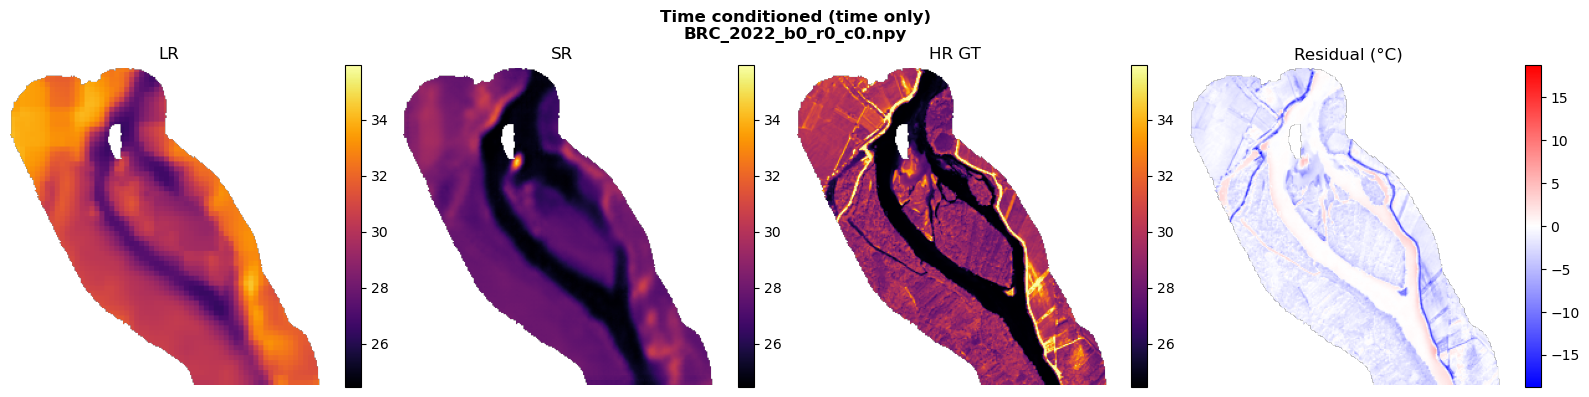

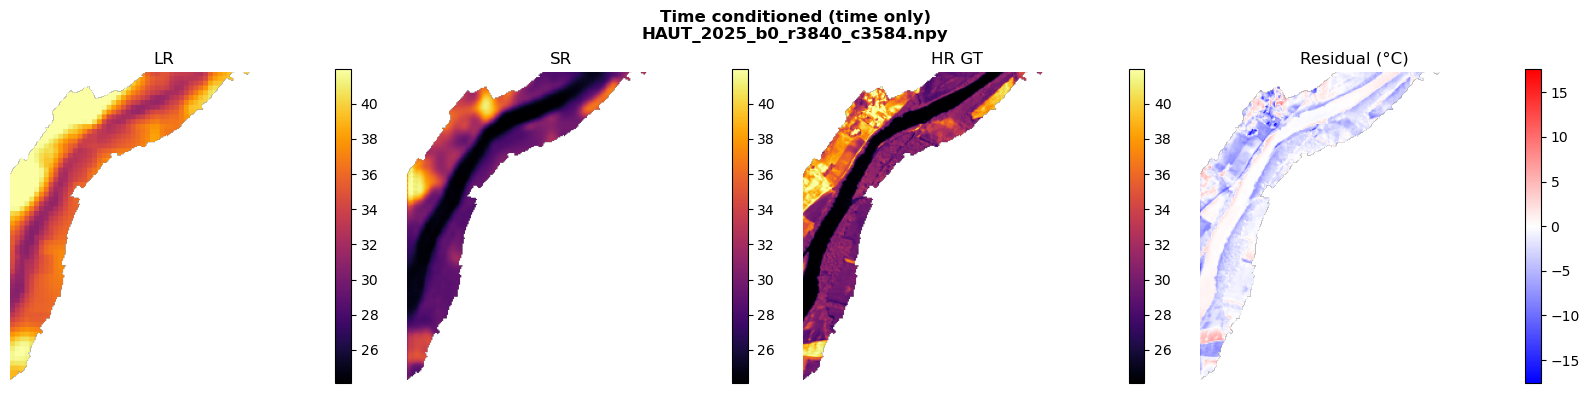

In [10]:
# Plot results
for s_idx, sample in enumerate(samples):

    fname = sample["fname"]

    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # Build batch for model
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}

    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        sr = model(batch)

    # Denormalize SR
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()

    #mask invalid regions
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    # Residual
    residual = sr_celsius - hr_np

    res_lim = (np.nanmax(np.abs(residual))if np.isfinite(residual).any()else 5)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    fig.suptitle(f"Time conditioned (time only)\n{fname}",fontsize=12,fontweight="bold")

    # LR
    im = axes[0].imshow(lr_np,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[0].set_title("LR")
    axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    # SR
    im = axes[1].imshow(sr_celsius,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[1].set_title("SR")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # HR
    im = axes[2].imshow( hr_np,cmap="inferno", vmin=vmin,vmax=vmax)
    axes[2].set_title("HR GT")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Residual
    im = axes[3].imshow(residual,cmap="bwr",vmin=-res_lim,vmax=res_lim)
    axes[3].set_title("Residual (°C)")
    axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

    torch.cuda.empty_cache()